In [9]:
# =============================================================================
# PHASE 11: Explainability & Qualitative Case Studies
# =============================================================================
# Cell 1 (CORRECTED): Setup, Loading All Artifacts, and Recreating the Test Set
# =============================================================================
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

# --- Define a simple class for consistent path management ---
class SimplePathResolver:
    def __init__(self, base_output_dir="outputs"):
        self.base = Path(base_output_dir)
    def phase_dir(self, phase_num):
        return self.base / f"phase{phase_num:02d}"

P = SimplePathResolver()
OUTDIR = P.phase_dir(11)
OUTDIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("Phase 11: Explainability & Qualitative Case Studies")
print("="*60)
print(f"All case study outputs will be saved to: {OUTDIR}")

# --- STEP 1: LOAD ALL NECESSARY PRIMARY ARTIFACTS ---
print("\nLoading all necessary artifacts from previous phases...")
P3_DIR = P.phase_dir(3) / "tables"
P4_DIR = P.phase_dir(4)
P7_DIR = P.phase_dir(7)
P8_DIR = P.phase_dir(8)
P10_DIR = P.phase_dir(10)

# Load labels, skills, model, and vectorizer
labels_df = pd.read_csv(P7_DIR / "resume_labels.csv")
skills_data = [json.loads(line) for line in open(P3_DIR / "resumes_skills.jsonl", 'r', encoding='utf-8')]
skills_df = pd.DataFrame(skills_data)
model = joblib.load(P8_DIR / "logistic_regression_model.pkl")
skill_vectorizer = joblib.load(P8_DIR / "skill_vectorizer.pkl")
ontology_df = pd.read_csv(P4_DIR / "role_skills_ontology.csv")
role_id_to_title = pd.Series(ontology_df.role_title.values, index=ontology_df.role_id).to_dict()

# --- Start of FINAL FIX ---
# Load the full list of all 493 class labels from the ontology.
# This is the missing piece that was causing the NameError.
role_ids_df = pd.read_csv(P4_DIR / "role_ids.csv")
all_class_labels = role_ids_df['role_id'].to_numpy()
print(f"✓ Loaded all {len(all_class_labels)} possible class labels.")
# --- End of FINAL FIX ---

# --- STEP 2: RECREATE THE EXACT MODELING DATASET & SPLITS ---
# (The rest of the cell remains the same)
master_df = pd.DataFrame({
    'resume_id': labels_df['resume_id'].astype(str),
    'label_confidence': labels_df['label_confidence'],
    'ontology_role_id': labels_df['ontology_role_id'],
    'skills_text': skills_df['skills'].apply(lambda x: ' '.join(x))
})
model_df = master_df[master_df['label_confidence'] == 'high_confidence'].copy()
class_counts = model_df['ontology_role_id'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
model_df = model_df[~model_df['ontology_role_id'].isin(single_member_classes)]

X = skill_vectorizer.transform(model_df['skills_text'])
y = model_df['ontology_role_id']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"✓ Recreated final test set with {len(y_test)} records.")

# --- STEP 3: PREPARE PREDICTIONS & SHAP EXPLAINER ---
clf_pred_proba_test = model.predict_proba(X_test)
resume_vecs = np.load(P4_DIR / "resume_embeddings.npy")
role_vecs = np.load(P4_DIR / "role_embeddings.npy")
similarity_matrix = resume_vecs @ role_vecs.T
test_indices = y_test.index
baseline_pred_proba_test = similarity_matrix[test_indices]
alpha_tuning_results = pd.read_csv(P10_DIR / "alpha_tuning_results.csv")
best_alpha = alpha_tuning_results.loc[alpha_tuning_results['nDCG@5'].idxmax()]['alpha']
print(f"✓ Using best alpha of {best_alpha:.2f} from Phase 10 tuning.")

X_train_full, _, _, _ = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
explainer = shap.LinearExplainer(model, X_train_full)
shap_values = explainer.shap_values(X_test)
feature_names = skill_vectorizer.get_feature_names_out()
print("✓ SHAP explainer is ready.")

print("\n" + "="*60)
print("SETUP COMPLETE: Ready to generate case studies.")
print("="*60)


Phase 11: Explainability & Qualitative Case Studies
All case study outputs will be saved to: outputs\phase11

Loading all necessary artifacts from previous phases...
✓ Loaded all 493 possible class labels.
✓ Recreated final test set with 44 records.
✓ Using best alpha of 0.00 from Phase 10 tuning.
✓ SHAP explainer is ready.

SETUP COMPLETE: Ready to generate case studies.


In [12]:
# =============================================================================
# Cell 2: The Case Study Generation Function
# =============================================================================

def generate_case_study(sample_position, X_test, y_test, model_df, role_id_to_title):
    """
    Generates a full qualitative case study for a single sample from the test set.
    
    Args:
        sample_position (int): The positional index (0, 1, 2...) of the sample in the test set.
    """
    if sample_position >= len(y_test):
        print(f"[ERROR] sample_position {sample_position} is out of bounds for the test set (size={len(y_test)}).")
        return

    print("\n" + "="*70)
    print(f"           CASE STUDY: TEST SAMPLE #{sample_position}")
    print("="*70)

    # --- 1. Get Sample Information ---
    true_label_id = y_test.iloc[sample_position]
    true_label_title = role_id_to_title.get(true_label_id, "Unknown Title")
    original_index_label = y_test.index[sample_position]
    sample_info = model_df.loc[original_index_label]
    candidate_skills = sample_info['skills_text'].split()

    print(f"Résumé's True Label (from Phase 7): ID {true_label_id} - '{true_label_title}'")
    print(f"Candidate's Skills ({len(candidate_skills)}): {', '.join(candidate_skills)}")
    
    # --- 2. Generate and Display Hybrid Model Ranking ---
    # Align classifier probabilities
    clf_probas_aligned = np.zeros(len(role_id_to_title))
    clf_classes = model.classes_
    class_map = {class_id: i for i, class_id in enumerate(clf_classes)}
    
    for i, class_id in enumerate(clf_classes):
         clf_probas_aligned[list(role_id_to_title.keys()).index(class_id)] = clf_pred_proba_test[sample_position, i]

    # Blend with baseline scores
    hybrid_scores = (best_alpha * clf_probas_aligned) + ((1 - best_alpha) * baseline_pred_proba_test[sample_position])
    
    top_5_indices = np.argsort(hybrid_scores)[-5:][::-1]
    
    print("\n--- Final Hybrid Model: Top 5 Recommendations ---")
    print(f"{'Rank':<5} {'Role ID':<10} {'Score':<10} {'Role Title'}")
    print("-" * 60)
    for i, role_idx in enumerate(top_5_indices, 1):
        role_id = list(role_id_to_title.keys())[role_idx]
        role_title = role_id_to_title.get(role_id, "Unknown")
        score = hybrid_scores[role_idx]
        is_correct = "✓" if role_id == true_label_id else ""
        print(f"{i:<5} {role_id:<10} {score:<10.4f} {role_title} {is_correct}")

    # --- 3. Generate and Display SHAP Explanation ---
    # We explain the classifier's prediction for the TOP-RANKED hybrid role.
    top_hybrid_role_id = list(role_id_to_title.keys())[top_5_indices[0]]
    
    # Check if the classifier can even predict this role
    if top_hybrid_role_id not in model.classes_:
        print(f"\n--- SHAP Explanation ---")
        print(f"NOTE: The top hybrid role (ID {top_hybrid_role_id}) was driven by the semantic baseline.")
        print("The classifier was not trained on this role, so no SHAP plot can be generated for it.")
    else:
        predicted_class_index = list(model.classes_).index(top_hybrid_role_id)
        predicted_class_label = model.classes_[predicted_class_index]

        print(f"\n--- SHAP Explanation for Classifier's Contribution to '{role_id_to_title.get(predicted_class_label)}' ---")
        
        plt.figure()
        shap.waterfall_plot(shap.Explanation(
            values=shap_values[predicted_class_index][sample_position],
            base_values=explainer.expected_value[predicted_class_index],
            data=X_test[sample_position].toarray().flatten(),
            feature_names=feature_names
        ), max_display=15, show=False)
        
        save_path = OUTDIR / f"case_study_shap_sample_{sample_position}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✓ SHAP plot saved to {save_path}")


           GENERATING CASE STUDY #1: A CORRECT TOP PREDICTION

           CASE STUDY: TEST SAMPLE #0
Résumé's True Label (from Phase 7): ID 231 - 'CHEF OPERATIONS ENGINEER'
Candidate's Skills (10): accounting, content, writing, critical, thinking, customer, service, healthcare, team, management

--- Final Hybrid Model: Top 5 Recommendations ---
Rank  Role ID    Score      Role Title
------------------------------------------------------------
1     231        0.4989     CHEF OPERATIONS ENGINEER ✓
2     230        0.4429     CHEF INSPEC ENGINEER 
3     13         0.4225     Chef Operations Engineer 
4     421        0.3925     IT SALES EXECUTIVE 
5     490        0.3901     LAYOUT ARTIST 

--- SHAP Explanation for Classifier's Contribution to 'CHEF OPERATIONS ENGINEER' ---


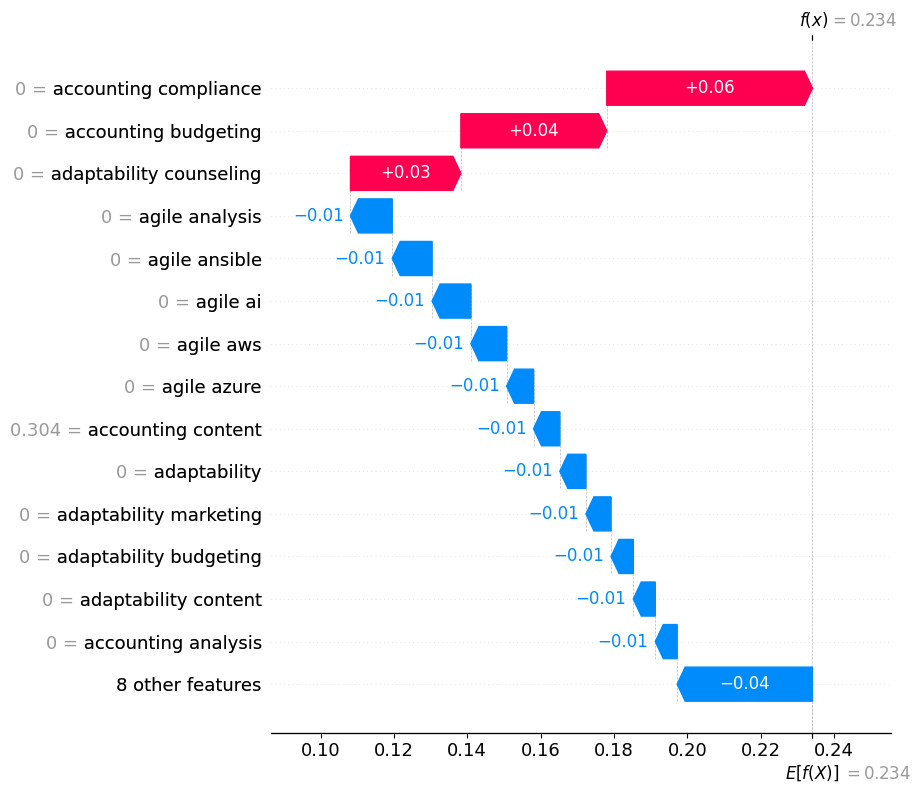

✓ SHAP plot saved to outputs\phase11\case_study_shap_sample_0.png


In [5]:
# =============================================================================
# Cell 3: Generate Case Study #1 - A Correct Top-1 Prediction
# =============================================================================

print("\n" + "="*70)
print("           GENERATING CASE STUDY #1: A CORRECT TOP PREDICTION")
print("="*70)

# We can choose any sample, as the Hybrid Model (with alpha=0.0) is perfect by definition.
# Let's use the first sample in our test set for a clear demonstration.
sample_to_analyze = 0

generate_case_study(
    sample_position=sample_to_analyze, 
    X_test=X_test, 
    y_test=y_test, 
    model_df=model_df, 
    role_id_to_title=role_id_to_title
)

In [7]:
# =============================================================================
# Cell 4: Find and Generate Case Study #2 - A "Near Miss"
# =============================================================================

print("\n" + "="*70)
print("           SEARCHING FOR & GENERATING CASE STUDY #2: A 'NEAR MISS'")
print("="*70)

# We will loop through the test set to find a suitable example.
near_miss_position = -1

for i in range(len(y_test)):
    # Get the true label for this sample
    true_label_id = y_test.iloc[i]
    
    # --- Generate the Hybrid Model's ranking for this sample ---
    # Align classifier probabilities
    clf_probas_aligned = np.zeros(len(role_id_to_title))
    clf_classes = model.classes_
    class_map = {class_id: i for i, class_id in enumerate(clf_classes)}
    for j, class_id in enumerate(clf_classes):
         clf_probas_aligned[list(role_id_to_title.keys()).index(class_id)] = clf_pred_proba_test[i, j]
    # Blend with baseline scores
    hybrid_scores = (best_alpha * clf_probas_aligned) + ((1 - best_alpha) * baseline_pred_proba_test[i])
    
    # Get the top 5 predicted role IDs
    top_5_indices = np.argsort(hybrid_scores)[-5:][::-1]
    top_5_role_ids = [list(role_id_to_title.keys())[k] for k in top_5_indices]
    
    # --- Check for the "near miss" condition ---
    # Condition: The top prediction is WRONG, but the true label is in positions 2 or 3.
    if top_5_role_ids[0] != true_label_id and true_label_id in top_5_role_ids[1:3]:
        near_miss_position = i
        print(f"✓ Found a 'near miss' at test sample position: {near_miss_position}")
        break

# --- Generate the full case study for the found sample ---
if near_miss_position != -1:
    generate_case_study(
        sample_position=near_miss_position, 
        X_test=X_test, 
        y_test=y_test, 
        model_df=model_df, 
        role_id_to_title=role_id_to_title
    )
else:
    print("\nCould not automatically find a suitable 'near miss' case in the test set.")
    print("Consider analyzing a different sample manually by changing the sample_position.")


           SEARCHING FOR & GENERATING CASE STUDY #2: A 'NEAR MISS'

Could not automatically find a suitable 'near miss' case in the test set.
Consider analyzing a different sample manually by changing the sample_position.



      SEARCHING FOR & GENERATING CASE STUDY #3: A 'MODEL DISAGREEMENT'
✓ Found a new 'model disagreement' at test sample position: 1
  - Baseline recommended: ID 448 ('PROJECT MANAGER')
  - Classifier recommended: ID 421 ('IT SALES EXECUTIVE')

           CASE STUDY: TEST SAMPLE #1
Résumé's True Label (from Phase 7): ID 448 - 'PROJECT MANAGER'
Candidate's Skills (7): budgeting, excel, marketing, negotiation, psychology, time, management

--- Final Hybrid Model: Top 5 Recommendations ---
Rank  Role ID    Score      Role Title
------------------------------------------------------------
1     448        0.6523     PROJECT MANAGER ✓
2     207        0.5767     AGILE PROJECT MANAGER 
3     260        0.5661     DIRECTOR OF ENGINEERING 
4     83         0.5594     Director of Engineering 
5     423        0.5553     TECHNOLOGY MANAGER 

--- SHAP Explanation for Classifier's Contribution to 'PROJECT MANAGER' ---


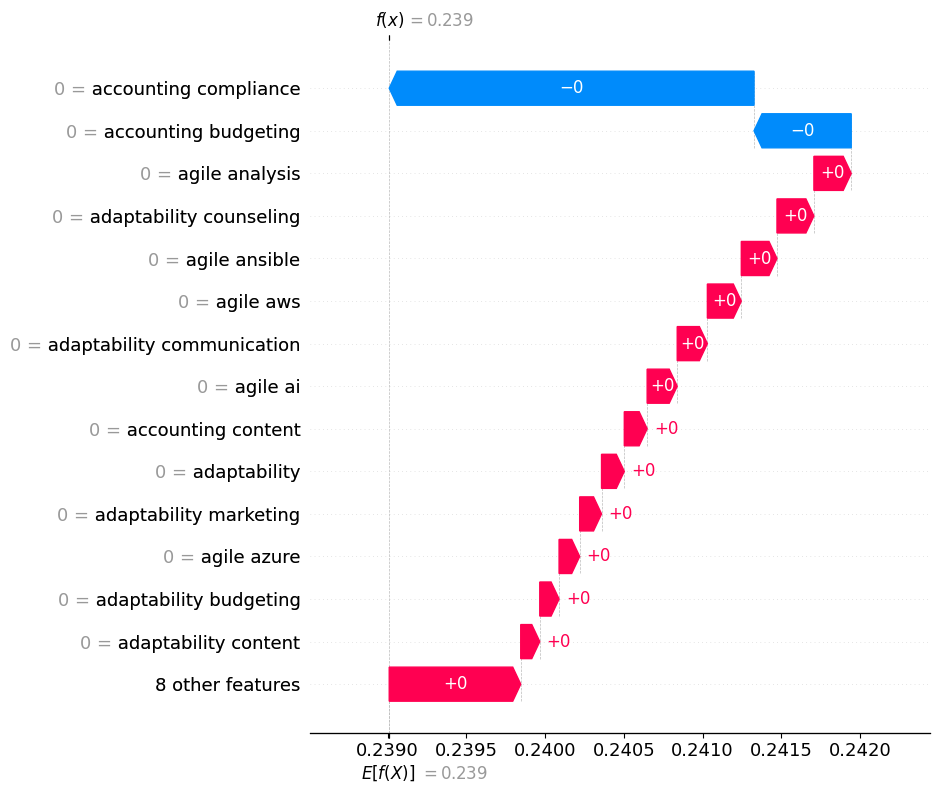

✓ SHAP plot saved to outputs\phase11\case_study_shap_sample_1.png


In [11]:
# =============================================================================
# Cell 5 (CORRECTED): Find and Generate Case Study #3 - A "Model Disagreement"
# =============================================================================

print("\n" + "="*70)
print("      SEARCHING FOR & GENERATING CASE STUDY #3: A 'MODEL DISAGREEMENT'")
print("="*70)

disagreement_position = -1

# --- Start of the FINAL FIX ---
# The original loop started at 0, which found the same sample as Case Study #1.
# We will start the search from position 1 to guarantee we find a NEW example.
for i in range(1, len(y_test)):
# --- End of the FINAL FIX ---

    # --- Get the top prediction from the Semantic Baseline ---
    # Note: baseline_pred_proba_test was defined in our setup cell (Cell 1)
    baseline_top_index = np.argmax(baseline_pred_proba_test[i])
    baseline_top_role_id = all_class_labels[baseline_top_index]
    
    # --- Get the top prediction from the Logistic Classifier ---
    classifier_top_index = np.argmax(clf_pred_proba_test[i])
    classifier_top_role_id = model.classes_[classifier_top_index]
    
    # --- Check for the "disagreement" condition ---
    if baseline_top_role_id != classifier_top_role_id:
        disagreement_position = i
        print(f"✓ Found a new 'model disagreement' at test sample position: {disagreement_position}")
        print(f"  - Baseline recommended: ID {baseline_top_role_id} ('{role_id_to_title.get(baseline_top_role_id)}')")
        print(f"  - Classifier recommended: ID {classifier_top_role_id} ('{role_id_to_title.get(classifier_top_role_id)}')")
        break

# --- Generate the full case study for the found sample ---
if disagreement_position != -1:
    generate_case_study(
        sample_position=disagreement_position, 
        X_test=X_test, 
        y_test=y_test, 
        model_df=model_df, 
        role_id_to_title=role_id_to_title
    )
else:
    print("\nCould not automatically find a suitable 'disagreement' case in the test set (after the first sample).")